In [1]:
from pathlib import Path

dataset = Path("datasets/face_mask/archive/dataset/images")

print(dataset.exists())

True


In [2]:
train = list((dataset / "train").glob("*.jpg")) + list((dataset / "train").glob("*.jpeg"))
valid = list((dataset / "valid").glob("*.jpg")) + list((dataset / "valid").glob("*.jpeg"))
test = list((dataset / "test").glob("*.jpg")) + list((dataset / "test").glob("*.jpeg"))

print("Train:", len(train))
print("Validation:", len(valid))
print("Test:", len(test))
print("Total:", len(train)+len(valid)+len(test))

Train: 692
Validation: 99
Test: 117
Total: 908


In [3]:
classes_file = dataset / "classes.txt"

with open(classes_file) as f:
    classes = [line.strip() for line in f]

print(classes)

['no_mask', 'mask']


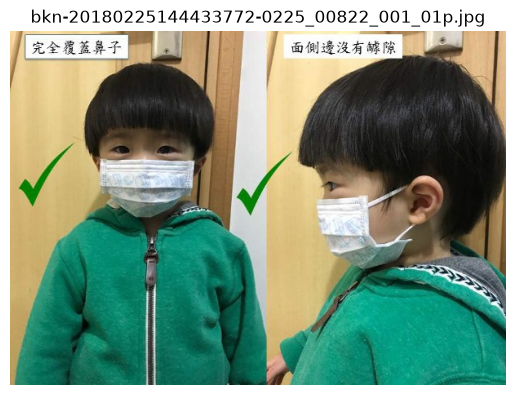

In [4]:
import random
from PIL import Image
import matplotlib.pyplot as plt

img_path = random.choice(train)

img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.title(img_path.name)
plt.show()

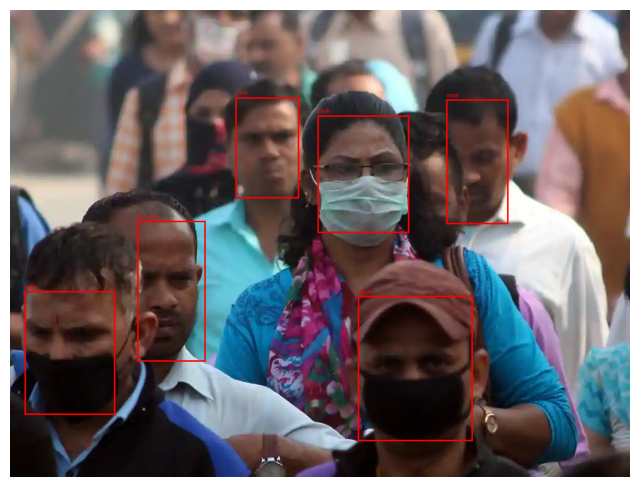

In [5]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Pick a random image
img_path = random.choice(train)

# Matching label file
label_path = img_path.with_suffix(".txt")

# Open image
img = Image.open(img_path)
draw = ImageDraw.Draw(img)

w, h = img.size

# Draw every bounding box
with open(label_path) as f:
    for line in f:
        cls, x, y, bw, bh = map(float, line.split())

        x1 = (x - bw/2) * w
        y1 = (y - bh/2) * h
        x2 = (x + bw/2) * w
        y2 = (y + bh/2) * h

        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)

        if int(cls) < len(classes):
            draw.text((x1, y1-15), classes[int(cls)], fill="red")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [6]:
from collections import Counter

counter = Counter()

for folder in ["train", "valid", "test"]:
    for txt in (dataset / folder).glob("*.txt"):
        with open(txt) as f:
            for line in f:
                cls = int(line.split()[0])
                counter[classes[cls]] += 1

print(counter)

Counter({'mask': 3828, 'no_mask': 1073})


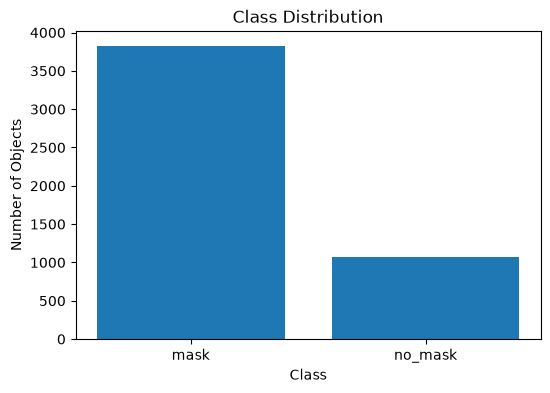

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(counter.keys(), counter.values())

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Objects")

plt.show()